#

In [ ]:
---
execute:
  eval: false
  echo: true
  warning: false
format:
  html:
    code-fold: false
---

Importing the packages.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

Loading the MNIST dataset.

In [2]:
digits = load_digits()
X = digits.data
y = digits.target

Instantiating and fitting the methods.

In [ ]:
pca = PCA(n_components=2)
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
mapper = umap.UMAP(n_components=2, min_dist=0.1, random_state=42)

X_pca = pca.fit_transform(X)
X_tsne = tsne.fit_transform(X)
X_umap = mapper.fit_transform(X)

Plotting the results.

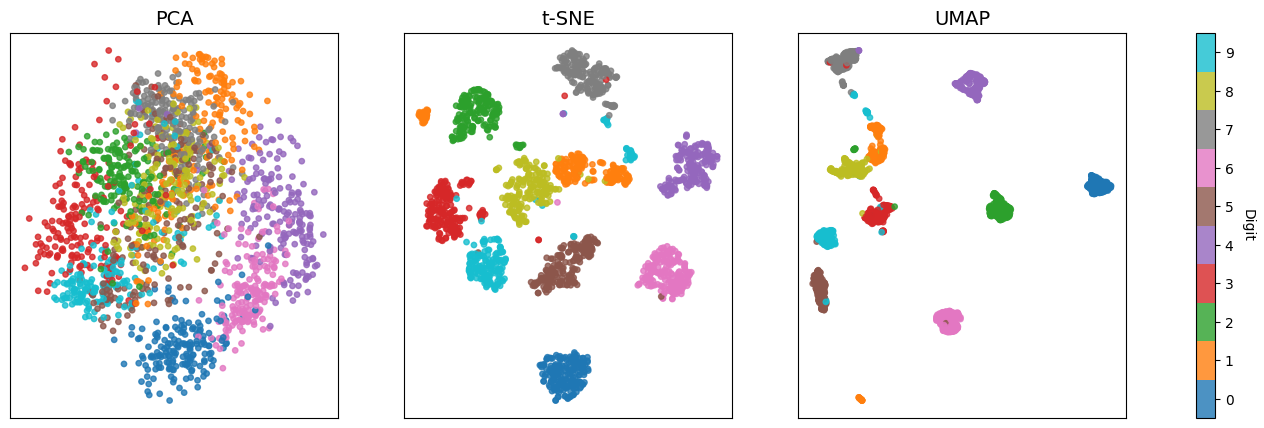

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cmap = plt.get_cmap('tab10')

def plot_embedding(ax, X_embedded, title):
    scatter = ax.scatter(X_embedded[:, 0], X_embedded[:, 1], c=y, cmap=cmap, s=15, alpha=0.8)
    ax.set_title(title, fontsize=14)
    ax.set_xticks([])
    ax.set_yticks([])
    return scatter

plot_embedding(axes[0], X_pca, "PCA")
plot_embedding(axes[1], X_tsne, "t-SNE")
scatter = plot_embedding(axes[2], X_umap, "UMAP")

cbar = fig.colorbar(scatter, ax=axes.ravel().tolist(), boundaries=np.arange(-0.5, 10.5, 1), ticks=np.arange(0, 10, 1))
cbar.set_label('Digit', rotation=270, labelpad=15)

plt.show()